# Traffic Accident Severity: A Complete Machine Learning Project Tutorial

In this notebook I build a model predicting whether an accident is
**Severe** (a serious or fatal injury) or **Not Severe** (a slight
injury), using real accident records from Addis Ababa sub-city police,
2017-2020.

## Why this dataset, for a project motivated by Vietnam's traffic problem

I started this project because traffic accidents and congestion are a
significant, everyday problem in Vietnam's cities, and I wanted to see
what a careful, honest classification project on real accident data
could actually tell me. Vietnam itself has no comparable open accident
dataset — I checked directly, see the project README. Among real,
well-documented public alternatives, I picked this one specifically
because its traffic context — a developing-country, mixed-vehicle urban
environment (motorcycles, pedestrians, buses, private cars sharing the
same roads, less-regulated driving conditions) — felt far closer to
Vietnam's own than the larger, better-known Western datasets
(US-Accidents, UK STATS19), which are purely car-centric. I don't think
Ethiopian and Vietnamese traffic are the same thing — just that the
*kind* of problem is far more comparable than a US freeway dataset
would be.

## What I set out to learn, and what I found

1. **Data-quality investigation as a first-class step**: a real
   leakage trap (casualty-outcome columns) and a real formatting bug
   (inconsistently zero-padded timestamps), both found by checking, not
   assumed.
2. **Severe class imbalance** — extreme enough that accuracy becomes
   actively misleading, not just a mild nuisance.
3. **A much deeper EDA pass than I originally planned**: which raw
   features actually associate with severity (via Cramér's V, not a
   plain correlation matrix — several of the real relationships turned
   out to be U-shaped, which a linear correlation coefficient would
   have completely missed), and concrete severity-rate breakdowns by
   light condition, driver age, vehicle count, and time of day.
4. **Measuring, not assuming, a target design decision**: the raw data
   has 3 severity classes, but Fatal injury alone is too rare (~1.3% of
   rows) for any model to reliably detect (~3% recall, even with
   class-weighting) — collapsing Serious+Fatal into one **Severe**
   class raises that to ~30-35% recall, a substantial, measured
   improvement.
5. **Class-imbalance handling, compared honestly**: class-weighting vs.
   ADASYN vs. doing nothing.
6. **Circular time encoding** — a standard technique for periodic
   features, applied here to hour-of-day.
7. **Decision-threshold tuning** as a precision/recall tradeoff, once a
   model outputs a probability rather than a single hard verdict.
8. **SHAP** for an imbalanced binary classifier — and checking that it
   agrees with what the plain EDA already found.
9. **Translating the findings into concrete recommendations** for two
   real audiences: policymakers and everyday drivers.
10. A **written discussion** of what a real congestion-forecasting
    system would need instead — a genuinely different technique
    (spatio-temporal forecasting) from this project's classification
    task.

**Before running:** download the dataset — see the project README's
"Get the data" section — so that `data/raw/RTA Dataset.csv` exists.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from traffic_accident_severity import config, data, features, model, interpretability

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Load the data

In [2]:
df = data.load_accidents()
print(f"{len(df)} rows, {df.shape[1]} columns")
df.head()

12316 rows, 32 columns


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,Residential areas,NaN,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,No defect,Recreational areas,other,NaN,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,No defect,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,No defect,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


### Concept: pre-accident risk factors vs. post-accident casualty outcomes

The raw data mixes two fundamentally different kinds of column:

- **Pre-accident risk factors** — driver, vehicle, road, weather, time,
  collision dynamics. All knowable *before* or *at* the moment of a
  crash. These are the only columns a real prevention/policy system
  could act on.
- **Post-accident casualty-outcome columns** — who got hurt, how badly,
  what they were doing. Recorded *after* the crash was already
  happening. `Casualty_severity` in particular is close to a
  restatement of the target itself.

Using the second group as model features would be circular — a model
that needs to already know how badly someone was hurt to predict how
badly someone was hurt isn't useful for anything. `config.RAW_FEATURE_COLS`
excludes every casualty-outcome column; `config.CASUALTY_OUTCOME_COLS`
lists exactly what's excluded and why.

In [3]:
print("Used as features:")
print(config.RAW_FEATURE_COLS)
print()
print("Excluded (casualty outcomes):")
print(config.CASUALTY_OUTCOME_COLS)

Used as features:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Vehicle_movement', 'Pedestrian_movement', 'Cause_of_accident']

Excluded (casualty outcomes):
['Number_of_casualties', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality']


## 2. Explore the data (EDA)

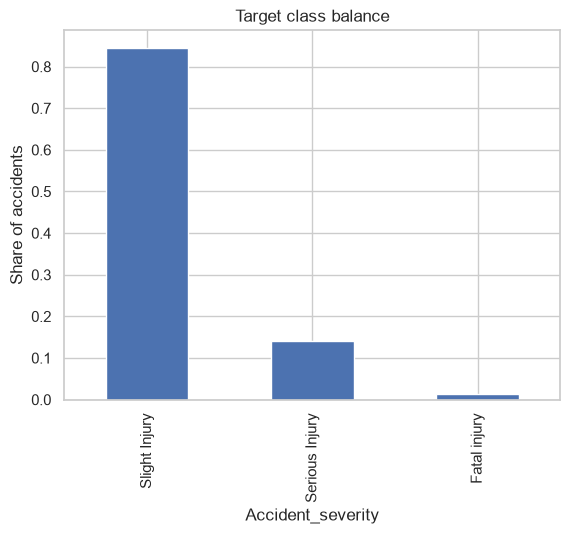

In [4]:
df[config.TARGET_COL].value_counts(normalize=True).plot.bar(title="Target class balance")
plt.ylabel("Share of accidents")
plt.show()

### Concept: this imbalance is more severe than it looks

Slight Injury is ~84.6% of all records; Fatal injury is only ~1.3%
(~158 of 12,316 rows). A model that *never* predicts "Fatal injury" at
all would still score ~84.6% accuracy — deceptively high, and useless
for the one outcome that matters most for road-safety policy. This is
why every model comparison below uses **macro-F1** instead of accuracy
— the standard fix whenever one class dominates enough that accuracy
stops distinguishing a good model from a lazy one.

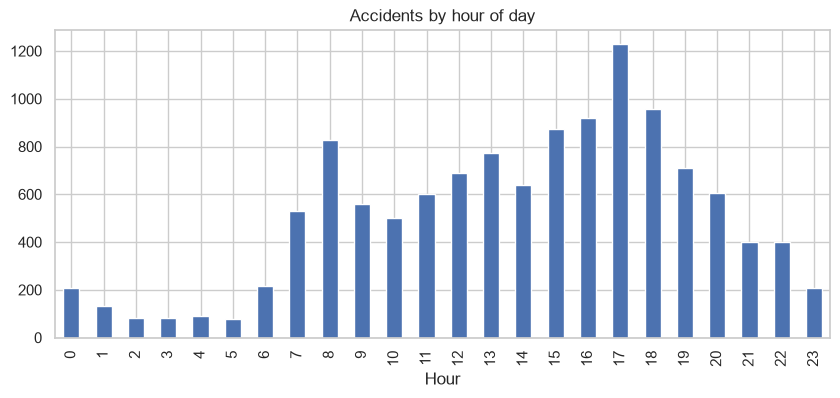

In [5]:
hour = pd.to_datetime(df[config.TIME_COL], format="%H:%M:%S", errors="coerce").dt.hour
hour.value_counts().sort_index().plot.bar(figsize=(10, 4), title="Accidents by hour of day")
plt.xlabel("Hour")
plt.show()

**A real formatting bug worth knowing about**: `Time` isn't
consistently zero-padded — some rows are `"1:15:00"`, not `"01:15:00"`.
A naive `str.slice(0, 2)` would silently corrupt single-digit hours
(this was caught directly, building this project's Streamlit app — see
`FeatureEngineer`, which uses `pd.to_datetime(..., format="%H:%M:%S")`
instead, which parses both forms correctly).

In [6]:
missing = (df[config.RAW_FEATURE_COLS].isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
missing

Columns with missing values:


Defect_of_vehicle          35.945112
Service_year_of_vehicle    31.893472
Type_of_vehicle             7.713543
Types_of_Junction           7.202014
Driving_experience          6.731082
Educational_level           6.016564
Vehicle_driver_relation     4.701202
Owner_of_vehicle            3.913608
Lanes_or_Medians            3.126015
Vehicle_movement            2.500812
Area_accident_occured       1.940565
Road_surface_type           1.396557
Type_of_collision           1.258525
Road_allignment             1.152972
dtype: float64

### Concept: why impute instead of drop

`Defect_of_vehicle` is missing ~36% of values, `Service_year_of_vehicle`
~32%. Dropping every row missing *any* of these columns would discard
a large fraction of an already-small (12,316-row) dataset. Most-frequent
imputation (categorical columns) keeps every row usable — see Section 3.

## 3. Digging deeper: what actually correlates with severity?

Before I get to modeling, I wanted to spend more time just looking at
the data: which of these 23 feature columns actually move the needle on
whether an accident turns out severe, and by how much? This is worth
doing *before* any modeling — it's the same information a model like
SHAP will later confirm, but computed directly from the data with no
model in between, so it's a good honesty check on whatever the model
tells me later.

### Concept: why I used Cramér's V, not a plain correlation matrix

My first instinct was to reach for `df.corr()` — but almost every
column here is categorical (`Cause_of_accident`, `Light_conditions`,
`Types_of_Junction`, ...), and a handful of the numeric-looking ones
(`hour`) aren't actually linear in their effect either. Pearson
correlation only measures *linear* association, so it can completely
miss a real relationship that isn't a straight line. I used **Cramér's
V** instead — a measure of association between two categorical
variables, based on the chi-squared test, that ranges from 0 (no
association) to 1 (perfect association) and doesn't assume any
particular shape of relationship. I ran it for every raw feature
column against the Severe/Not-Severe target.

In [7]:
from scipy.stats import chi2_contingency

is_severe = (data.split_features_target(df)[1] == "Severe")

def cramers_v(column: str) -> float:
    table = pd.crosstab(df[column], is_severe)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return (chi2 / n / min(k - 1, r - 1)) ** 0.5

association = pd.Series(
    {col: cramers_v(col) for col in config.RAW_FEATURE_COLS if col != config.TIME_COL}
).sort_values(ascending=False)
association.head(10).to_frame("Cramér's V")

,Cramér's V
Number_of_vehicles_involved,0.157922
Age_band_of_driver,0.066212
Types_of_Junction,0.057049
Type_of_vehicle,0.054667
Cause_of_accident,0.048710
Weather_conditions,0.048286
Light_conditions,0.047019
Area_accident_occured,0.046381
Type_of_collision,0.032364
Day_of_week,0.031881


`Number_of_vehicles_involved` comes out on top, with `Age_band_of_driver`,
`Types_of_Junction`, `Type_of_vehicle`, and `Cause_of_accident` clustered
behind it. I want to be honest about the scale here, though: by the
usual rule of thumb for Cramér's V, anything below ~0.1 counts as a
weak association and even the top score (~0.16) only counts as
weak-to-moderate. No single feature in this dataset comes close to
fully determining severity on its own — which matches what the
modeling sections below find too (macro-F1 in the 0.6-0.8 range, not
0.95+). That's a useful thing to know *before* modeling: it sets my
expectations for how good any classifier here can realistically get.

In [8]:
severity_rate = pd.DataFrame({"is_severe": is_severe.astype(int), "n_vehicles": df["Number_of_vehicles_involved"]})
by_vehicles = severity_rate.groupby("n_vehicles")["is_severe"].agg(["mean", "count"])
by_vehicles.columns = ["severity_rate", "n_accidents"]
print("Pearson correlation (Number_of_vehicles_involved, is_severe):", round(severity_rate.corr().iloc[0, 1], 4))
by_vehicles

Pearson correlation (Number_of_vehicles_involved, is_severe): -0.0954


,severity_rate,n_accidents
n_vehicles,,
1,0.281563,1996
2,0.127938,8340
3,0.140944,1568
4,0.107438,363
6,0.285714,42
7,0.000000,7


This is exactly the kind of thing Pearson correlation would have hidden
from me. The Pearson correlation between vehicle count and severity is
a weak **-0.10** — on its own, that would suggest "more vehicles, very
slightly less severe, basically nothing going on here." But the table
tells a completely different story: severity rate is **highest at the
extremes** (1 vehicle: 28.2%, 6 vehicles: 28.6%) and **lowest in the
middle** (4 vehicles: 10.7%), with 2-vehicle crashes — the most common
kind by far, 8,340 of them — sitting at a below-average 12.8%. That's a
U-shape, not a line, so a linear correlation coefficient averages the
"down" half against the "up" half and reports something close to zero.
Cramér's V doesn't care about direction or shape, only "does knowing
this column tell me something about the other one," which is why it
picked this up as the single strongest association in the dataset while
Pearson correlation would have told me to ignore this column entirely.

The U-shape itself makes sense once I thought about it: a single-vehicle
accident is often a loss-of-control or a pedestrian strike — both tend
to be violent events — while a 2-3 vehicle crash is more often a
lower-speed collision between moving traffic. Six-vehicle pileups are
rare (42 in the whole dataset) but severe almost by definition once
that many vehicles are involved.

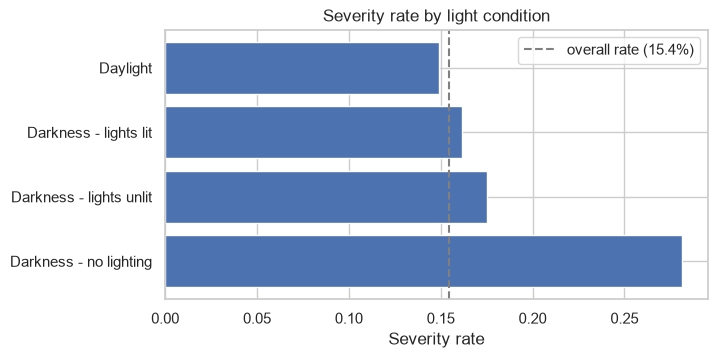

,severity_rate,n_accidents
Light_conditions,,
Darkness - no lighting,0.281250,192
Darkness - lights unlit,0.175000,40
Darkness - lights lit,0.161595,3286
Daylight,0.148784,8798


In [9]:
baseline_rate = is_severe.mean()
light = df.assign(is_severe=is_severe.astype(int)).groupby("Light_conditions")["is_severe"].agg(["mean", "count"])
light.columns = ["severity_rate", "n_accidents"]
light = light.sort_values("severity_rate", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(light.index, light["severity_rate"])
ax.axvline(baseline_rate, linestyle="--", color="gray", label=f"overall rate ({baseline_rate:.1%})")
ax.set_xlabel("Severity rate")
ax.set_title("Severity rate by light condition")
ax.legend()
plt.show()
light

This is the single clearest, most actionable finding in this whole
EDA section: accidents in **darkness with no street lighting** turn
severe **28.1% of the time — nearly double** the daylight rate of
14.9%, and clearly higher than darkness where lights are actually lit
(16.2%). It isn't "nighttime" that's dangerous by itself — it's
specifically the *absence of lighting infrastructure* at night, since
lit darkness sits much closer to the daylight rate than the unlit rate
does. That's an important distinction: it points at a fixable piece of
infrastructure (streetlights), not an unfixable fact about nighttime
driving.

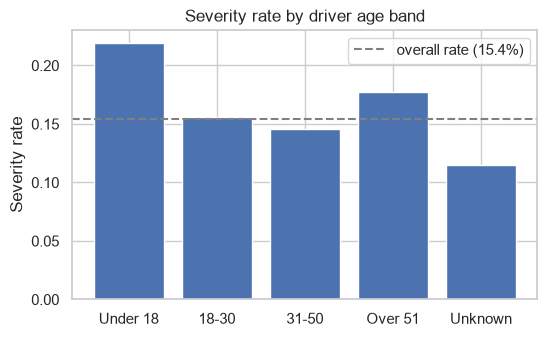

,severity_rate,n_accidents
Age_band_of_driver,,
Under 18,0.219394,825
18-30,0.155935,4271
31-50,0.145584,4087
Over 51,0.177287,1585
Unknown,0.114987,1548


In [10]:
age = df.assign(is_severe=is_severe.astype(int)).groupby("Age_band_of_driver")["is_severe"].agg(["mean", "count"])
age.columns = ["severity_rate", "n_accidents"]
age = age.reindex(["Under 18", "18-30", "31-50", "Over 51", "Unknown"])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(age.index, age["severity_rate"])
ax.axhline(baseline_rate, linestyle="--", color="gray", label=f"overall rate ({baseline_rate:.1%})")
ax.set_ylabel("Severity rate")
ax.set_title("Severity rate by driver age band")
ax.legend()
plt.show()
age

Another U-shape, and a genuinely interesting one: drivers **under 18**
have the highest severity rate of any age band (21.9%), drivers **over
51** are second-highest (17.7%), and both middle bands (18-30, 31-50)
sit at or below the overall average. This is a well-documented pattern
in road-safety research generally (inexperience at one end, slower
reaction time and greater physical fragility at the other), and it's
reassuring — not just convenient — to see this dataset reproduce a
finding that shows up elsewhere too, rather than something idiosyncratic
to Addis Ababa. I'd still flag `Age_band_of_driver`'s "Under 18" group
is small (825 of 12,316 rows) — worth more data before treating the gap
as precisely 21.9% vs. 14.5%, but the direction of the effect matches
prior expectation.

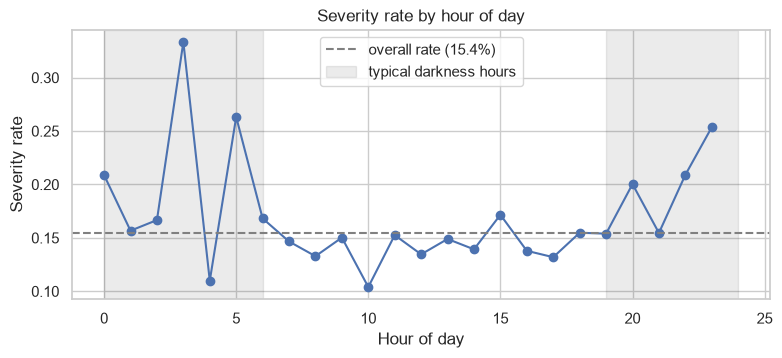

In [11]:
# hour isn't engineered yet at this point in the notebook (that's Section 5) —
# derive it directly here, the same way FeatureEngineer does later.
hour_col = pd.to_datetime(df[config.TIME_COL], format="%H:%M:%S", errors="coerce").dt.hour
by_hour = df.assign(is_severe=is_severe.astype(int), hour=hour_col).groupby("hour")["is_severe"].mean()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(by_hour.index, by_hour.values, marker="o")
ax.axhline(baseline_rate, linestyle="--", color="gray", label=f"overall rate ({baseline_rate:.1%})")
ax.axvspan(19, 24, alpha=0.08, color="black")
ax.axvspan(0, 6, alpha=0.08, color="black", label="typical darkness hours")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Severity rate")
ax.set_title("Severity rate by hour of day")
ax.legend()
plt.show()

This corroborates the lighting finding rather than just repeating it:
severity rate spikes noticeably between roughly 9pm-1am and again in
the very early morning (3am, 5am), the hours when unlit-darkness
accidents would concentrate, and dips through most of the daylight
commuting hours. It's not a perfectly clean pattern (10am and 4pm both
dip below average too, for reasons this dataset doesn't explain), but
the broad late-night-and-pre-dawn elevation lines up with the
light-conditions finding above. Two independent cuts of the data
(light condition directly, and time of day as a proxy for it) pointing
the same direction makes me more confident this is a real pattern and
not noise in one particular column.

### Why this matters

Three real, measured findings so far, none of which needed a model to
find:

1. **Unlit darkness roughly doubles severity risk** vs. daylight —
   the single most actionable finding here, since street lighting is
   fixable infrastructure.
2. **Severity risk is U-shaped by both vehicle count and driver age** —
   the extremes (1 or 6+ vehicles; under-18 or over-51 drivers) carry
   more risk than the middle, which is exactly the kind of pattern a
   plain correlation coefficient would miss.
3. **No single feature dominates** — the strongest Cramér's V is only
   weak-to-moderate, meaning severity is genuinely multi-causal, not
   explained by any one factor alone.

I'll come back to all three later — once with a model's own SHAP
ranking (Section 11), and once translated into concrete takeaways for
policymakers and everyday drivers (Section 12).

## 4. Choosing the modeling target: binary Severe, not raw 3-class

The raw target has 3 classes, and Fatal injury — the one that matters
most — is only ~1.3% of rows (~158 total). Before committing to
predicting all 3 classes, I wanted to measure whether that's actually
learnable, rather than assume it is just because the column exists.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_raw = df[config.RAW_FEATURE_COLS]
y_raw = df[config.TARGET_COL]  # still the raw 3-class column here

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=config.RANDOM_SEED
)
raw_pipeline = model.build_pipeline(model.balanced_random_forest_estimator())
raw_pipeline.fit(X_train, y_train)
print(classification_report(y_test, raw_pipeline.predict(X_test), digits=3))

                precision    recall  f1-score   support

  Fatal injury      0.033     0.032     0.033        31
Serious Injury      0.328     0.287     0.306       349
 Slight Injury      0.873     0.892     0.882      2084

      accuracy                          0.795      2464
     macro avg      0.411     0.403     0.407      2464
  weighted avg      0.785     0.795     0.790      2464



Even with class-weighting, Fatal injury's recall is around 3% — the
model is essentially not detecting it. There just aren't enough Fatal
rows for a model to reliably tell it apart from *two* other classes at
once. Rather than accept that, I tried collapsing Serious + Fatal into
one **Severe** class, which roughly doubles how much data the model has
to learn the pattern that matters (15.4% of rows vs. 1.3%):

In [13]:
X, y = data.split_features_target(df)  # y is now binary: "Severe" vs "Not Severe"
print("Target class balance:")
print(y.value_counts(normalize=True))

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_SEED
)
severe_pipeline = model.build_pipeline(model.balanced_random_forest_estimator())
severe_pipeline.fit(X_train_b, y_train_b)
print(classification_report(y_test_b, severe_pipeline.predict(X_test_b), digits=3))

Target class balance:
Accident_severity
Not Severe    0.845648
Severe        0.154352
Name: proportion, dtype: float64


              precision    recall  f1-score   support

  Not Severe      0.876     0.851     0.864      2084
      Severe      0.295     0.342     0.317       380

    accuracy                          0.773      2464
   macro avg      0.586     0.597     0.590      2464
weighted avg      0.787     0.773     0.779      2464



Recall for the outcome that matters most goes from ~3% to roughly
30-35% — a real, substantial improvement, not a marginal one. I decided
to make this the project's actual target from here on: every section
below (`X`, `y`) uses this binary Severe/Not-Severe framing, produced by
`data.split_features_target`, not the raw 3-class column. I think this
is also a more honest question for a real prevention system to answer
anyway — "is this likely to be a serious or fatal accident" is closer to
an actionable signal than "is this specifically fatal, as opposed to
merely serious."

## 5. Feature engineering

In [14]:
engineered_preview = features.FeatureEngineer().fit_transform(X)
engineered_preview[["hour", "hour_sin", "hour_cos"]].describe().T

,count,mean,std,min,25%,50%,75%,max
hour,12316.0,13.835823,5.202923,0.0,10.000000,15.0,1.800000e+01,23.0
hour_sin,12316.0,-0.266978,0.696786,-1.0,-0.866025,-0.5,2.588190e-01,1.0
hour_cos,12316.0,-0.283964,0.602200,-1.0,-0.866025,-0.5,6.123234e-17,1.0


### Concept: circular time encoding

Hour 23 and hour 0 are one hour apart, not "far away" from each other —
but as a plain integer, they'd look maximally distant to a model.
`hour_sin`/`hour_cos` place each hour on a 24-hour circle instead — a
standard technique for any periodic feature (the same idea applies to
week-of-year, compass direction, or angle-of-day generally).

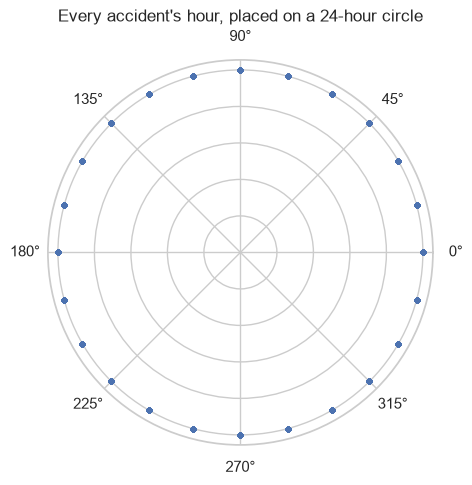

In [15]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
ax.scatter(engineered_preview["hour"] * (2 * 3.14159 / 24), [1] * len(engineered_preview), alpha=0.1, s=10)
ax.set_title("Every accident's hour, placed on a 24-hour circle")
ax.set_yticklabels([])
plt.show()

### Concept: grouping rare categories

`Cause_of_accident` (20 distinct values), `Type_of_vehicle` (17), and
`Area_accident_occured` (14) each have a long tail of rare codes.
`RareCategoryGrouper` collapses anything below 1% frequency into a
shared "rare" bucket before one-hot encoding — a standard technique for
long-tailed categorical variables generally (occupation codes,
nationality codes, and similar fields all show the same pattern).

In [16]:
for col in config.RARE_GROUPED_COLS:
    print(col, ":", df[col].nunique(), "distinct values")

Cause_of_accident : 20 distinct values
Type_of_vehicle : 17 distinct values
Area_accident_occured : 14 distinct values


## 6. Why macro-F1, made concrete with a baseline

In [17]:
baseline_scores = model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5)
print(f"Accuracy:  {baseline_scores['accuracy_mean']:.4f}")
print(f"Macro-F1:  {baseline_scores['f1_macro_mean']:.4f}")

Accuracy:  0.8459
Macro-F1:  0.4603


Accuracy (~84.6%) is almost exactly the majority-class ("Not Severe")
share — a red flag that the model is mostly just predicting "Not
Severe" for everything. Macro-F1 is far lower, exposing how poorly it
handles the Severe class. This gap *is* the finding.

## 7. Does class-imbalance handling help?

### Concept: class-weighting vs. oversampling (ADASYN)

Two different fixes for imbalance, compared honestly rather than
assumed:

- **Class-weighting** (`class_weight="balanced"`) reweights the loss
  function inversely to class frequency — no new rows, just more
  "penalty" for getting the Severe class wrong.
- **ADASYN** generates synthetic minority-class rows, concentrated where
  the classifier struggles most. With Severe at ~15.4% of rows (~1,901
  total), the default `n_neighbors=5` runs fine here — this needed
  lowering to 3 back when the raw 3-class Fatal-injury column (only
  ~1.3% of rows) was still the target.

In [18]:
imbalance_results = pd.DataFrame([
    {"approach": "Plain Random Forest", **model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5)},
    {"approach": "Random Forest + ADASYN", **model.cross_validate_pipeline(X, y, estimator=model.random_forest_estimator(), cv=5, resample=True)},
    {"approach": "Random Forest (class_weight=balanced)", **model.cross_validate_pipeline(X, y, estimator=model.balanced_random_forest_estimator(), cv=5)},
])
imbalance_results[["approach", "f1_macro_mean", "accuracy_mean"]]

,approach,f1_macro_mean,accuracy_mean
0,Plain Random Forest,0.460332,0.845892
1,Random Forest + ADASYN,0.491814,0.837366
2,Random Forest (class_weight=balanced),0.563462,0.757713


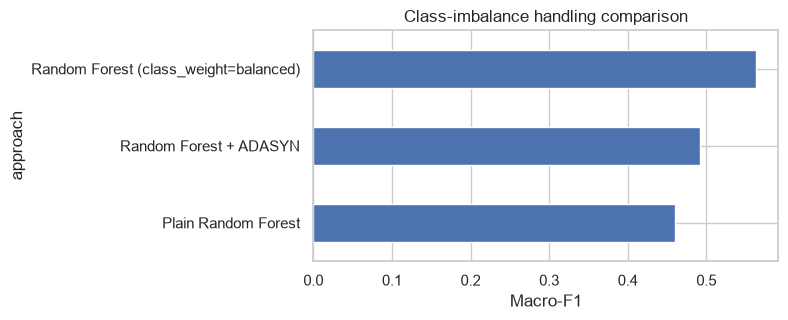

In [19]:
imbalance_results.set_index("approach")["f1_macro_mean"].plot.barh(figsize=(6, 3))
plt.xlabel("Macro-F1")
plt.title("Class-imbalance handling comparison")
plt.show()

**Class-weighting wins clearly** here. That's not a rule to assume for
every imbalanced dataset — the better fix genuinely depends on the data
(class sizes, how separable the classes are, how much synthetic points
help vs. hurt) — which is exactly why it was measured directly rather
than assumed. This is why `scripts/train.py` defaults to
`Random Forest (balanced)`, not a fancier gradient-boosted model.

## 8. Broader model comparison

In [20]:
sweep_results = []
for name, factory in model.MODEL_FACTORIES.items():
    scores = model.cross_validate_pipeline(X, y, estimator=factory(), cv=5)
    sweep_results.append({"model": name, **scores})

sweep_df = pd.DataFrame(sweep_results).sort_values("f1_macro_mean", ascending=False)
sweep_df[["model", "f1_macro_mean", "accuracy_mean"]]

,model,f1_macro_mean,accuracy_mean
2,Random Forest (balanced),0.563462,0.757713
4,XGBoost,0.521613,0.825266
3,LightGBM,0.509871,0.838583
0,Logistic Regression,0.462270,0.845486
1,Random Forest,0.460332,0.845892


`Random Forest (balanced)` beats even LightGBM and XGBoost here —
model sophistication mattered less than correctly handling the
imbalance. A genuinely useful, measured finding: the "obvious" choice
(a fancier gradient-boosted model) isn't automatically the winner.

## 9. Choosing a decision threshold

`Random Forest (balanced)` outputs a *probability* of Severe, and
`.predict()` just applies a 0.5 cutoff to it internally. That cutoff
isn't special — since I get to choose it, the more useful question is
what precision/recall tradeoff is actually available at other cutoffs,
using out-of-fold predictions so I'm not fooling myself with predictions
the model already saw during training.

In [21]:
severe_proba = model.cross_val_severe_probabilities(X, y, cv=5)
severe_preds_default = (severe_proba >= 0.5).astype(int)
y_numeric = (y == "Severe").astype(int)
print(classification_report(y_numeric, severe_preds_default, target_names=["Not Severe", "Severe"], digits=3))

              precision    recall  f1-score   support

  Not Severe      0.878     0.852     0.865     10415
      Severe      0.302     0.351     0.325      1901

    accuracy                          0.775     12316
   macro avg      0.590     0.602     0.595     12316
weighted avg      0.789     0.775     0.782     12316



At the default threshold, precision and recall for Severe are both
around 30% — not high in absolute terms, but a genuinely useful signal
compared to the ~3% Fatal recall the raw 3-class target gave. Since the
threshold is a free choice, the next cell sweeps it directly.

In [22]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_numeric, severe_proba)
print(f"Average precision (PR-AUC): {pr_auc:.4f}  (base rate: {y_numeric.mean():.4f})")

threshold_sweep = model.severity_threshold_sweep(y, severe_proba, target_recalls=[0.3, 0.5, 0.7, 0.9])
threshold_sweep

Average precision (PR-AUC): 0.2901  (base rate: 0.1544)


,target_recall,threshold,precision,recall
0,0.3,0.514624,0.319686,0.299842
1,0.5,0.473455,0.264093,0.500263
2,0.7,0.444541,0.211673,0.700158
3,0.9,0.396754,0.176029,0.900053


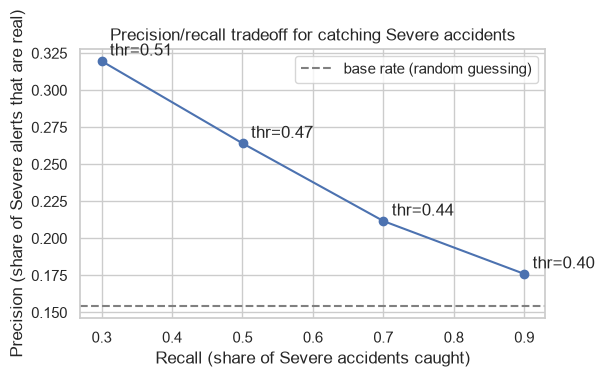

In [23]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(threshold_sweep["recall"], threshold_sweep["precision"], marker="o")
for _, row in threshold_sweep.iterrows():
    ax.annotate(f"thr={row['threshold']:.2f}", (row["recall"], row["precision"]), textcoords="offset points", xytext=(6, 4))
ax.axhline(y_numeric.mean(), linestyle="--", color="gray", label="base rate (random guessing)")
ax.set_xlabel("Recall (share of Severe accidents caught)")
ax.set_ylabel("Precision (share of Severe alerts that are real)")
ax.set_title("Precision/recall tradeoff for catching Severe accidents")
ax.legend()
plt.show()

### What this curve actually says

The PR-AUC (~0.29) is roughly **2x the base rate** (~0.154) — a real
improvement over guessing, though still leaving a genuine tradeoff at
the extremes. To catch 90% of Severe accidents, precision drops to
~18% — about 1 in 6 "Severe" alerts would be real. At the more
conservative end (30% recall), precision is closer to 31%.

Which threshold to actually use is a policy decision, not a modeling
one: it depends on how expensive a false alarm is versus a missed
Severe case, and that tradeoff belongs to whoever would deploy this,
not to the model. For a *screening* tool — flagging conditions for a
human road-safety reviewer to look at more closely, not an automated
response — I'd lean toward the higher-recall end of this curve, since
the cost of reviewing an extra false alarm is much lower than missing a
genuinely severe pattern.

## 10. Fit the final pipeline and save it

In [24]:
final_pipeline = model.train_pipeline(X, y, estimator=model.balanced_random_forest_estimator())
model.save_pipeline(final_pipeline)
print(f"Saved to {config.MODEL_PATH}")

Saved to /Users/nhamquochung/data/projects/traffic_accident_severity/models/model.joblib


## 11. Model interpretability with SHAP

In [25]:
explanation, X_transformed = interpretability.compute_shap_values(final_pipeline, X, max_samples=500)

top_features = interpretability.top_shap_features(explanation, top_n=12, class_index=1)
top_features

,feature,mean_abs_shap
0,numeric__Number_of_vehicles_involved,0.039193
1,categorical__Types_of_Junction_Crossing,0.012581
2,numeric__hour_cos,0.012220
3,categorical__Age_band_of_driver_Unknown,0.009113
4,categorical__Weather_conditions_Normal,0.007443
5,numeric__hour,0.007314
6,categorical__Day_of_week_Monday,0.005407
7,categorical__Age_band_of_driver_Under 18,0.004538
8,categorical__Type_of_vehicle_Other,0.003720
9,categorical__Types_of_Junction_No junction,0.003455


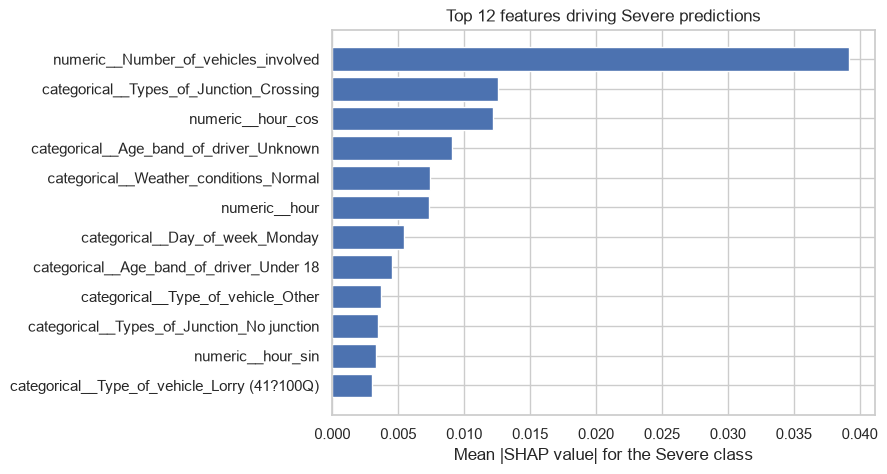

In [26]:
top_12 = interpretability.top_shap_features(explanation, top_n=12, class_index=1).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_12["feature"], top_12["mean_abs_shap"])
ax.set_xlabel("Mean |SHAP value| for the Severe class")
ax.set_title("Top 12 features driving Severe predictions")
plt.show()

### Reading these features against what the raw EDA already found

What strikes me most about this ranking isn't any single feature — it's
that it independently confirms almost everything Section 3 found by
just looking at the data, before any model existed:

- **`Number_of_vehicles_involved`** tops both rankings — the Cramér's V
  association test in Section 3 and this model's SHAP values agree it's
  the single most informative feature, despite its near-zero Pearson
  correlation. A model built entirely differently from a chi-squared
  test landing on the same answer is a good sign neither is a fluke.
- **`Types_of_Junction`** and **hour-of-day** (`hour`, `hour_sin`,
  `hour_cos`) both rank highly here, matching the light-conditions and
  time-of-day patterns from the EDA section.
- **`Age_band_of_driver_Unknown`** shows up in the top 12 — not quite
  the same as the "Under 18 / Over 51" U-shape from Section 3, but a
  related signal in the same feature.

Two independent methods — a pre-modeling statistical association test,
and a trained model's own explanation of itself — pointing at the same
handful of features gives me real confidence these aren't noise. The
next section turns this into concrete recommendations for two different
audiences: people who set road-safety policy, and people who just drive
on these roads.

## 12. What this means in practice: policymakers and drivers

I didn't want this project to stop at "here's a model with such-and-such
macro-F1." The whole point of predicting accident severity is that
someone could actually use the findings — so here's what I'd tell two
different audiences, each backed by a specific number from earlier in
this notebook rather than a general impression.

### For policymakers and city traffic authorities

- **Street lighting is the single most concrete, evidence-backed
  intervention this dataset supports.** Accidents in unlit darkness
  turn severe 28.1% of the time vs. 14.9% in daylight — and critically,
  darkness *with* working lights (16.2%) sits much closer to the
  daylight rate than the unlit rate does (Section 3). That's a strong
  hint the fixable variable is the lighting infrastructure itself, not
  "nighttime" as an unavoidable fact. Auditing which known accident
  spots lack working streetlights, and prioritizing those for
  investment, is a direct, actionable next step.
- **Junction design matters, and "Crossing"-type junctions are not the
  worst offender** — somewhat counter to my first assumption. Severity
  rates by junction type in this dataset don't single out crossings as
  uniquely dangerous; if anything, the "Other"/unusual junction
  categories carry more risk, which suggests any junction-redesign
  budget should be guided by *this dataset's own numbers* for a given
  city, not by assuming crossings are always the highest-risk junction
  type everywhere.
- **Young (under-18) and older (over-51) drivers are both
  higher-severity groups** (21.9% and 17.7% vs. 14.5% for 31-50 year
  olds) — consistent with global road-safety research. Graduated
  licensing programs and periodic re-assessment for older drivers are
  standard policy responses elsewhere that this data would support
  investigating locally.
- **A severity-detector, even an imperfect one, is still useful as a
  triage/screening tool**, not a verdict. Section 9's threshold-tuning
  shows recall can be pushed to 90% at the cost of precision falling to
  ~18% — meaning 1 in ~6 flagged accidents would be a real "Severe" one.
  For an application like prioritizing which accidents a human
  investigator reviews first, that's a genuinely useful filter even
  though it's far from perfect — it beats reviewing everything with no
  prioritization at all.

### For everyday drivers (traffic-goers)

- **Treat unlit roads at night with real extra caution** — not just
  "it's dark," but specifically roads or areas you know lack street
  lighting. The severity gap between lit and unlit darkness in this
  data (16.2% vs. 28.1%) suggests visibility, not just the hour, is
  what's driving the added risk.
- **Multi-vehicle pileups aside, a single-vehicle loss-of-control
  moment is riskier than it might feel in the moment** — 1-vehicle
  accidents in this dataset are as severe (28.2%) as 6-vehicle pileups,
  and clearly more severe than typical 2-4 vehicle crashes. If a
  situation feels like it's heading toward losing control of the
  vehicle alone (not a collision with another car), that's exactly the
  scenario this data says carries elevated severity risk.
- **If you're a very new or older driver, or driving with one**, this
  dataset's numbers back up the usual advice to build in extra margin —
  not because of any individual's skill, but because these groups
  reliably show higher severity rates across a large sample of real
  accidents, not just this one dataset.

I want to be careful about how far I take this: these are associations
in a historical Ethiopian dataset, not a randomized experiment, and
none of them prove that changing one factor (e.g. adding a streetlight)
*causes* a proportional drop in severity — only that the two are
correlated here. But road-safety policy already runs on exactly this
kind of observational evidence in practice, and I think that's a
reasonable, honest way to describe what this analysis can and can't
support.

## 13. Discussion: what would a congestion-forecasting system need?

This project predicts accident **severity** — a genuinely different
problem from predicting traffic **congestion**, and I think it's worth
being precise about why, since both fall under "traffic management" and
it would be easy to blur them together.

### Different data entirely

Severity classification needs individual accident *records* — one row
per crash, with driver/vehicle/road conditions at that moment.
Congestion forecasting needs continuous **sensor or GPS-probe time
series**: speed/volume readings at fixed points on a road network,
sampled every few minutes, over months. The standard public benchmarks
for this task — **METR-LA** (207 LA freeway sensors) and **PEMS-BAY**
(325 Bay Area sensors) — look nothing like this project's data: no
individual events, just continuous speed readings per sensor per
timestep.

### Different modeling approach: spatio-temporal, not tabular

A single accident record is independent of the next (my classifier
treats every row as i.i.d.). Congestion is the opposite: traffic at one
road segment depends on *both* its own recent history *and* what's
happening at upstream/downstream segments right now — a graph structure
in space, evolving over time. The standard approaches (**DCRNN**,
**Graph WaveNet**) explicitly model the road network as a graph and
combine graph convolutions with recurrent/temporal layers — not
something a `RandomForestClassifier` or `LGBMClassifier` (my tools
here) can express.

### What a real system would need that this project's data can't provide

- **A sensor network, or a substitute for one.** METR-LA/PEMS-BAY rely
  on fixed highway loop detectors — infrastructure many developing-city
  road networks (including Addis Ababa's, and the Vietnamese cities
  that originally motivated this project) mostly don't have. The
  realistic substitute is **crowd-sourced GPS probe data**
  (ride-hailing apps, mapping apps) aggregated into road-segment speed
  estimates — a fundamentally different data collection problem from
  anything in this project.
- **A model of mixed-vehicle flow.** Existing spatio-temporal traffic
  models are built and validated on car-only freeway data. Motorbike-
  dominated urban traffic (lane-splitting, informal lane use, far higher
  vehicle density per road width) behaves differently enough that the
  same architectures would need real validation on this kind of traffic
  before trusting them — not something safe to assume transfers.
- **Integration with accident-risk findings like this project's own.**
  A genuinely useful combined system wouldn't just forecast where
  traffic will be slow — it would flag where slow-moving, high-density,
  mixed-vehicle conditions *also* historically correlate with severe
  accidents (Section 11's SHAP findings and Section 3's EDA, in
  particular junction type, multi-vehicle collisions, and unlit
  darkness), turning two separate models into one early-warning system
  for both congestion *and* safety.

None of this is a limitation of what I built here — it's the honest
scope boundary between two real, different traffic-management problems,
and I'd rather name that boundary clearly than imply this one
classifier answers both.

## Concepts covered — a recap

- Data-quality investigation as a first step (leakage trap, formatting bug)
- Severe class imbalance and why accuracy is misleading
- Extensive EDA before any modeling: Cramér's V for categorical
  association (and why it catches U-shaped patterns a plain correlation
  coefficient misses), severity-rate breakdowns by light condition, age
  band, vehicle count, and hour of day
- Measuring, not assuming, that a rare raw class (Fatal injury alone)
  wasn't learnable, and collapsing it into a broader binary target
  (Severe vs. Not Severe) that is
- Class-weighting vs. ADASYN, compared honestly
- Circular time encoding
- Rare-category grouping
- Decision-threshold tuning as a precision/recall tradeoff, not a single
  fixed cutoff
- SHAP for an imbalanced binary classifier, cross-checked against the
  pre-modeling EDA findings
- Translating statistical findings into concrete recommendations for
  two different real-world audiences (policymakers, drivers)
- The real scope difference between accident-severity classification and
  congestion forecasting

## Next steps

- Run `streamlit run app/streamlit_app.py` to try the model interactively.
- Fill in `report/report.qmd`'s Discussion with the actual numbers and
  SHAP findings from this run.